# Adult Census Income — Binary Classification

## Goal

Predict whether a person's annual income is **above** or **at-or-below** $50,000
using the UCI/Kaggle Adult Census dataset (demographics, education, employment,
and financial fields).

This notebook walks through:

1. A quick data-quality pass and exploratory analysis
2. Feature preparation (grouping, encoding, scaling) wrapped in a single
   `scikit-learn` `Pipeline`
3. A bake-off between several classical classifiers, tuned with grid search
   and compared on cross-validated F1
4. A small PyTorch MLP tuned with Optuna, thrown in as an extra data point
5. Freezing the winning pipeline to disk so it can be reused for inference
   outside the notebook (see `inference.py` / `app_gui.py`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [4]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.6 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import optuna

In [6]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
import os
import joblib

DATA_PATH = "data/adult.csv"
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

## 1. Load and inspect

In [8]:
df = pd.read_csv("adult.csv")
print(df.shape)
df.sample(5, random_state=1)

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
391,31,Private,224234,HS-grad,9,Never-married,Transport-moving,Own-child,Black,Male,0,0,40,United-States,<=50K
1899,25,Private,149486,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Black,Male,0,0,40,United-States,<=50K
24506,36,Self-emp-not-inc,343721,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,30,?,>50K
32816,26,?,131777,Bachelors,13,Married-civ-spouse,?,Husband,White,Male,0,2002,40,United-States,<=50K
47892,30,Local-gov,44566,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [10]:
na_markers = (df == "?").sum()
na_markers = na_markers[na_markers > 0]

print("Columns using '?' as a missing-value marker:")
print(na_markers)
print("\nExact duplicate rows:", df.duplicated().sum())

Columns using '?' as a missing-value marker:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Exact duplicate rows: 52


## 2. Categorical fields — where the `?`s live

`workclass`, `occupation`, and `native-country` are the three fields that use
`"?"`. Rather than dropping those rows (roughly 7% of the data combined),
they're recoded as an explicit `"Unknown"` category — a missing workclass or
occupation may itself carry information about income.

In [11]:
for col in ["workclass", "occupation", "native-country"]:
    df[col] = df[col].replace("?", "Unknown")

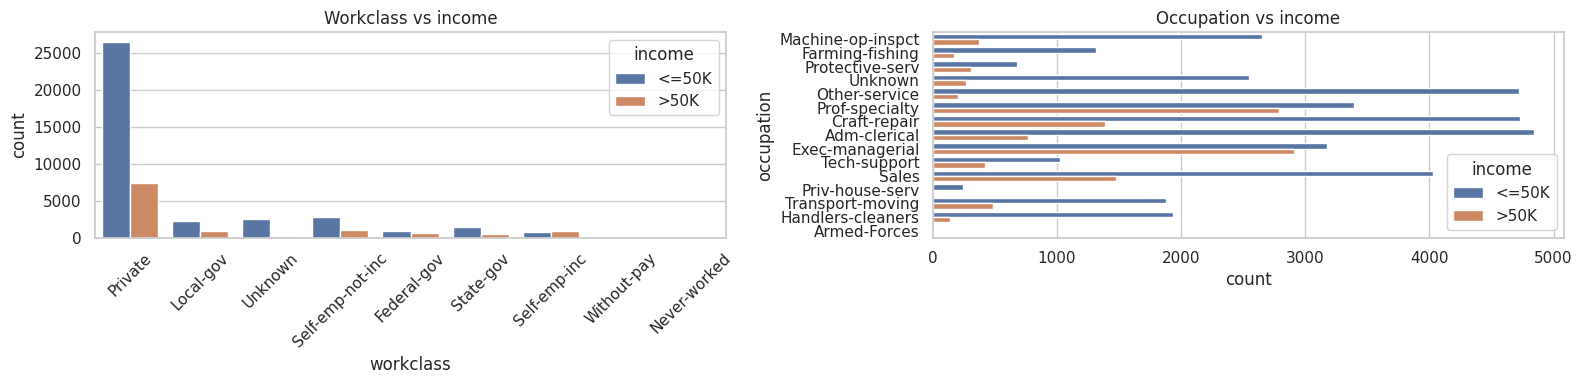

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.countplot(data=df, x="workclass", hue="income", ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Workclass vs income")

sns.countplot(data=df, y="occupation", hue="income", ax=axes[1])
axes[1].set_title("Occupation vs income")
plt.tight_layout()
plt.show()

### Education

`education` has 16 distinct levels, several of which are thin (e.g. individual
grade-school years). These are collapsed into six ordered attainment bands so
the ordinal structure of "more schooling" is preserved without the sparsity of
the raw categories.

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


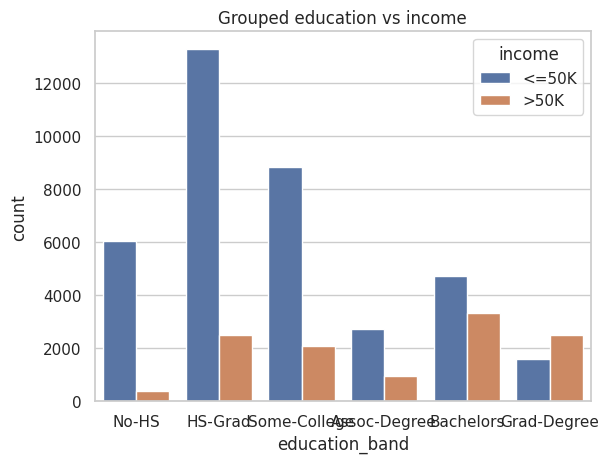

In [13]:
print(df["education"].value_counts())

EDUCATION_ORDER = [
    "No-HS", "HS-Grad", "Some-College",
    "Assoc-Degree", "Bachelors", "Grad-Degree",
]

_education_map = {
    "Preschool": "No-HS", "1st-4th": "No-HS", "5th-6th": "No-HS",
    "7th-8th": "No-HS", "9th": "No-HS", "10th": "No-HS",
    "11th": "No-HS", "12th": "No-HS",
    "HS-grad": "HS-Grad",
    "Some-college": "Some-College",
    "Assoc-voc": "Assoc-Degree", "Assoc-acdm": "Assoc-Degree",
    "Bachelors": "Bachelors",
    "Masters": "Grad-Degree", "Prof-school": "Grad-Degree", "Doctorate": "Grad-Degree",
}

df["education_band"] = df["education"].map(_education_map)
assert df["education_band"].isna().sum() == 0

sns.countplot(data=df, x="education_band", order=EDUCATION_ORDER, hue="income")
plt.title("Grouped education vs income")
plt.show()

### Marital status, relationship, demographics

Quick look at the remaining nominal fields before deciding how to encode
them.

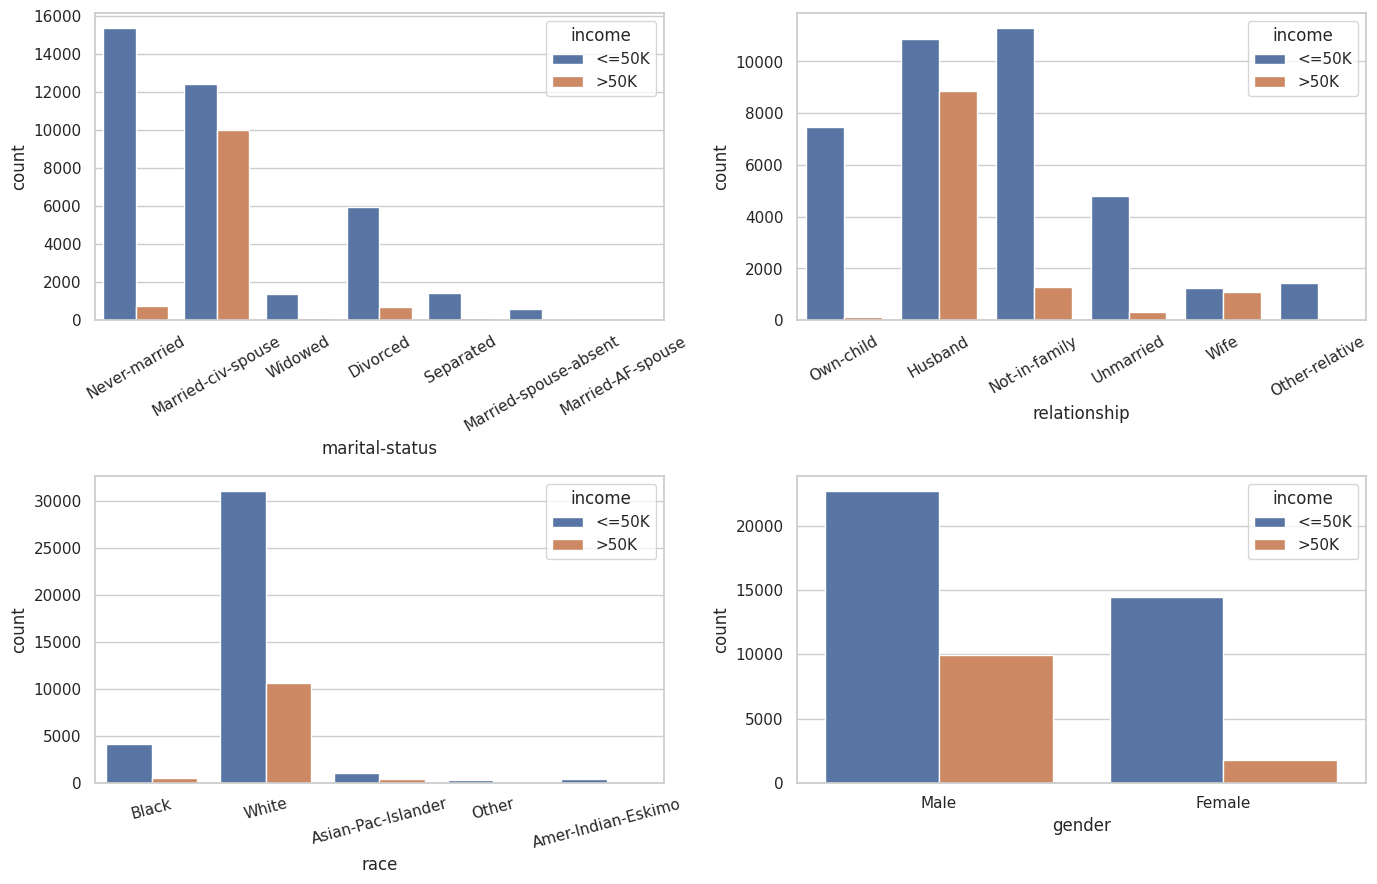

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.countplot(data=df, x="marital-status", hue="income", ax=axes[0, 0])
axes[0, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="relationship", hue="income", ax=axes[0, 1])
axes[0, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="race", hue="income", ax=axes[1, 0])
axes[1, 0].tick_params(axis="x", rotation=15)

sns.countplot(data=df, x="gender", hue="income", ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [15]:
print("Native country, top 10 by count:")
print(df["native-country"].value_counts().head(10))
print("\nTotal distinct countries:", df["native-country"].nunique())

Native country, top 10 by count:
native-country
United-States    43832
Mexico             951
Unknown            857
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64

Total distinct countries: 42


## 3. Numeric fields

In [16]:
NUMERIC_COLS = ["age", "capital-gain", "capital-loss", "hours-per-week"]
df[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


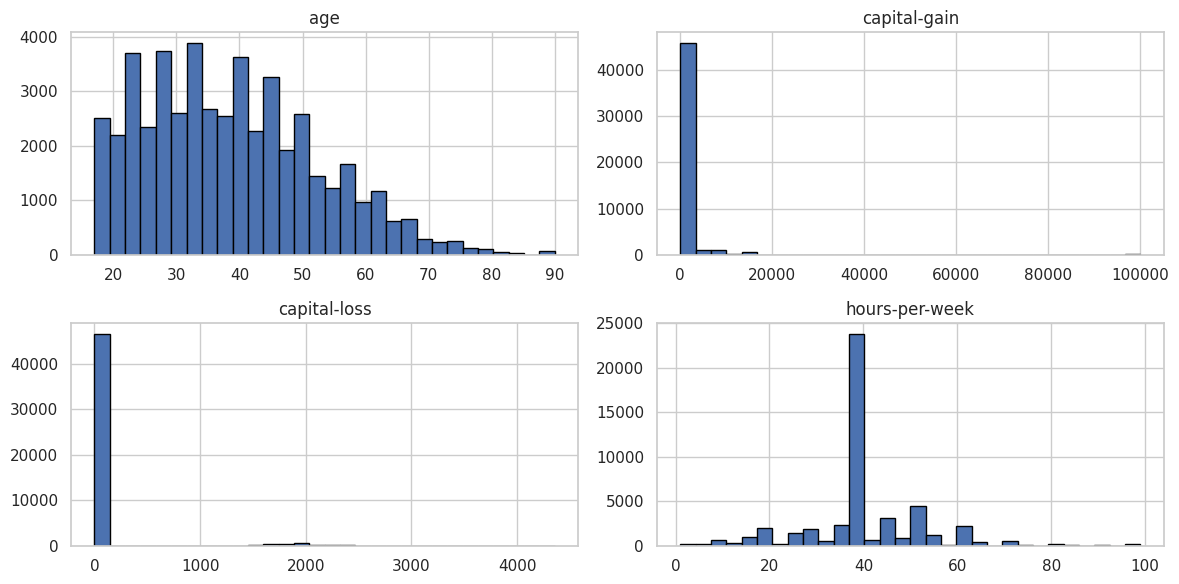

In [17]:
df[NUMERIC_COLS].hist(figsize=(12, 6), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

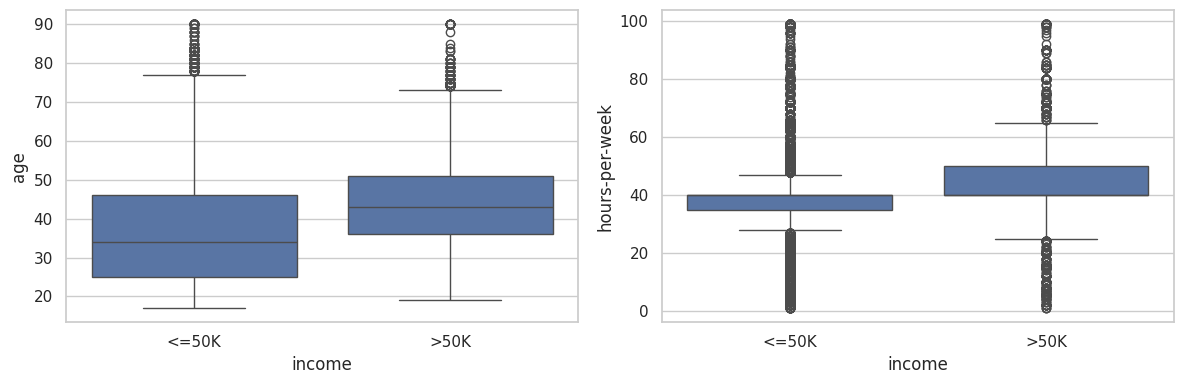

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="income", y="age", ax=axes[0])
sns.boxplot(data=df, x="income", y="hours-per-week", ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Target balance and income-rate by category

The target is imbalanced (roughly 3-to-1 toward `<=50K`), which is the reason
F1 rather than accuracy is used to compare models later.

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

income
<=50K    76.1%
>50K     23.9%
Name: proportion, dtype: object


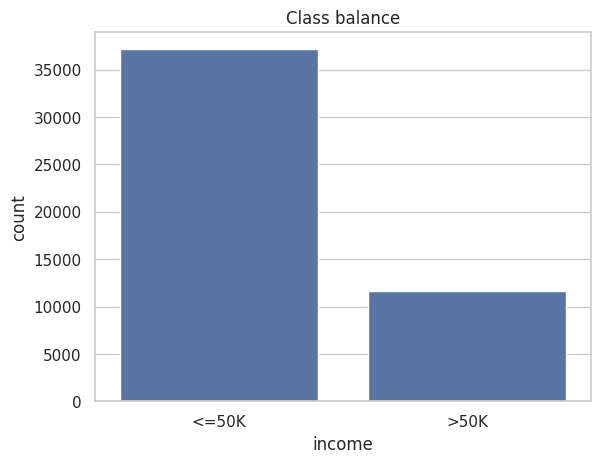

In [19]:
target_counts = df["income"].value_counts()
target_pct = df["income"].value_counts(normalize=True).mul(100).round(1)

print(target_counts)
print()
print(target_pct.astype(str) + "%")

sns.countplot(data=df, x="income")
plt.title("Class balance")
plt.show()

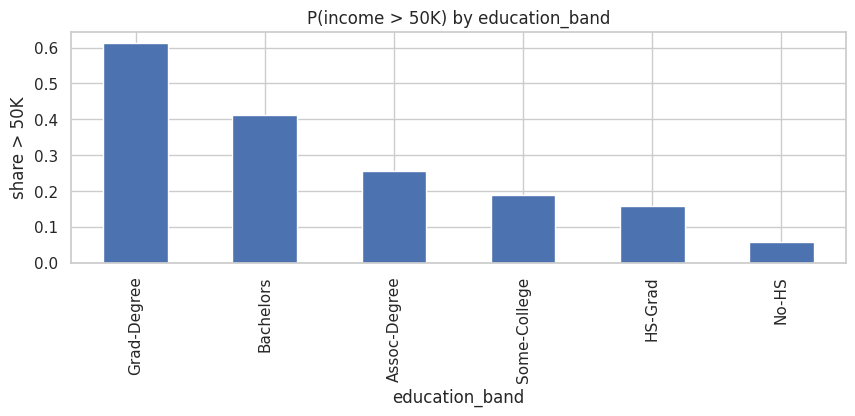

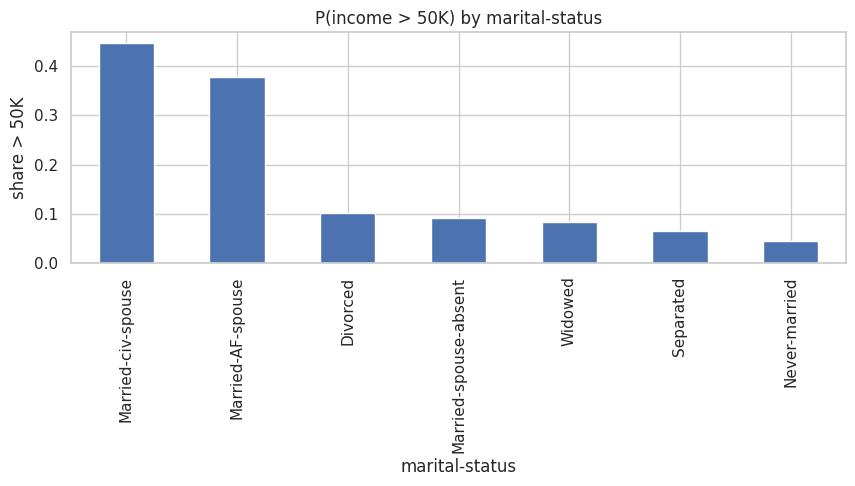

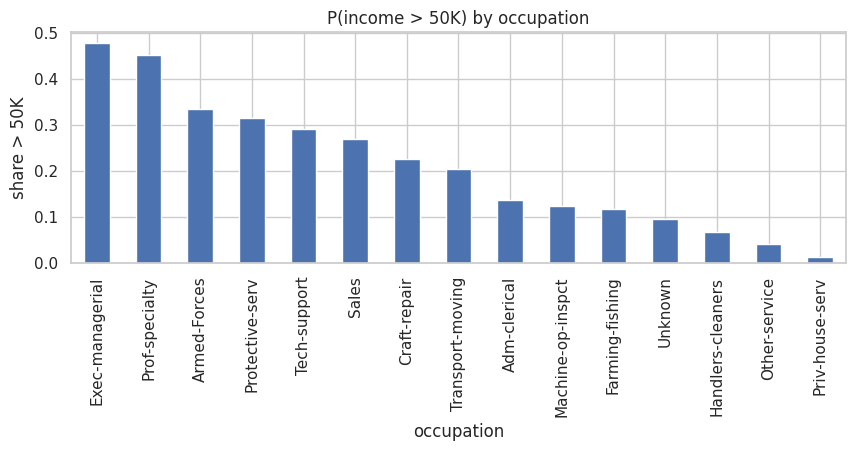

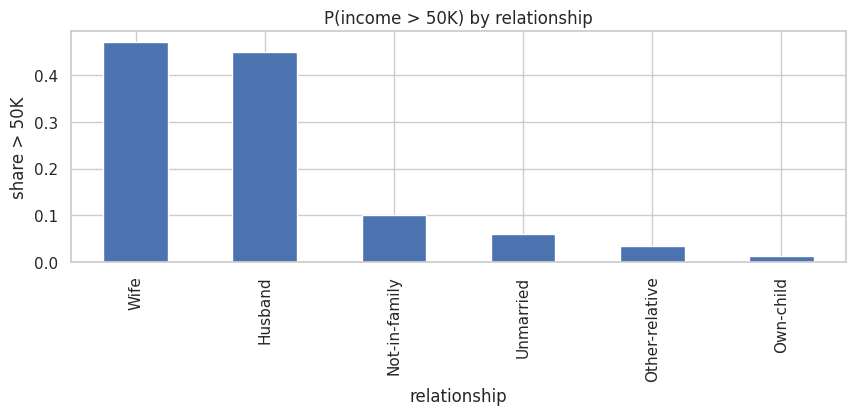

In [20]:
def income_rate_by(feature, data=df):
    """Share of records with income > 50K, per category of `feature`."""
    rate = (
        data.assign(over_50k=(data["income"] == ">50K").astype(int))
        .groupby(feature, observed=False)["over_50k"]
        .mean()
        .sort_values(ascending=False)
    )
    rate.plot(kind="bar", figsize=(10, 3), title=f"P(income > 50K) by {feature}")
    plt.ylabel("share > 50K")
    plt.show()
    return rate


for feat in ["education_band", "marital-status", "occupation", "relationship"]:
    income_rate_by(feat)

## 5. Building the preprocessing pipeline


In [21]:
from sklearn.preprocessing import FunctionTransformer

NOMINAL_COLS = [
    "workclass", "marital-status", "occupation",
    "relationship", "race", "gender", "native-country",
]
ORDINAL_COLS = ["education_band"]
LOG_NUMERIC_COLS = ["capital-gain", "capital-loss"]
PLAIN_NUMERIC_COLS = ["age", "hours-per-week"]

log_then_scale = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", RobustScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL_COLS),
        ("ordinal", OrdinalEncoder(categories=[EDUCATION_ORDER]), ORDINAL_COLS),
        ("numeric_skewed", log_then_scale, LOG_NUMERIC_COLS),
        ("numeric_plain", RobustScaler(), PLAIN_NUMERIC_COLS),
    ],
    remainder="drop",
)

In [22]:
feature_cols = NOMINAL_COLS + ORDINAL_COLS + NUMERIC_COLS

X = df[feature_cols].copy()
y = (df["income"] == ">50K").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((39073, 12), (9769, 12))

In [23]:
preprocessor.fit(X_train)

X_train_enc = preprocessor.transform(X_train)
X_test_enc = preprocessor.transform(X_test)

X_train_enc.shape

(39073, 91)

## 6. Model bake-off

Four classical classifiers, each with a small grid, compared under 5-fold
stratified cross-validation using F1 as the scoring metric.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "logistic_regression": (
        LogisticRegression(max_iter=5000, random_state=42),
        {"C": [0.01, 0.1, 1, 10]},
    ),
    "knn": (
        KNeighborsClassifier(n_jobs=1),
        {"n_neighbors": [5, 11, 21], "weights": ["uniform", "distance"]},
    ),
    "random_forest": (
        RandomForestClassifier(random_state=42, n_jobs=1),
        {"n_estimators": [200], "max_depth": [12, 20]},
    ),
    "hist_gradient_boosting": (
        HistGradientBoostingClassifier(random_state=42),
        {"max_depth": [None, 6, 10], "learning_rate": [0.05, 0.1]},
    ),
}



In [25]:
fitted_models = {}
leaderboard = []

for name, (estimator, grid) in candidates.items():
    search = GridSearchCV(estimator, grid, scoring="f1", cv=cv, n_jobs=-1)
    search.fit(X_train_enc, y_train)

    fitted_models[name] = search.best_estimator_
    leaderboard.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_f1": search.best_score_,
        "test_f1": f1_score(y_test, search.predict(X_test_enc)),
    })
    print(f"{name}: cv_f1={search.best_score_:.4f}")

logistic_regression: cv_f1=0.6447
knn: cv_f1=0.6665
random_forest: cv_f1=0.6779
hist_gradient_boosting: cv_f1=0.7073


## 7. A small neural net, for comparison

Tabular data doesn't especially call for a convolutional architecture, so
here it's a plain multi-layer perceptron instead — a couple of
`Linear -> BatchNorm -> ReLU -> Dropout` blocks, with `Optuna` searching over
width, depth, dropout, and learning rate.

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cpu


In [27]:
X_train_t = torch.tensor(np.asarray(X_train_enc), dtype=torch.float32)
X_test_t = torch.tensor(np.asarray(X_test_enc), dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

n_features = X_train_t.shape[1]

In [28]:
class IncomeMLP(nn.Module):
    def __init__(self, n_features, hidden_sizes, dropout):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_sizes:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [29]:
class TorchClassifier:
    """Thin sklearn-style wrapper so the torch model can share the
    confusion-matrix / leaderboard code path with the sklearn models."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(np.asarray(X), dtype=torch.float32).to(self.device)
            logits = self.model(x)
            return (torch.sigmoid(logits) > 0.5).int().cpu().numpy()

In [30]:
def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden = [trial.suggest_categorical(f"units_l{i}", [32, 64, 128]) for i in range(n_layers)]
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True
    )

    model = IncomeMLP(n_features, hidden, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(10):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    preds = TorchClassifier(model, device).predict(X_test_t)
    return f1_score(y_test_t.numpy(), preds)

In [31]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=True)
best_params = study.best_params
best_params

[I 2026-09-27 17:19:58,804] A new study created in memory with name: no-name-d92b7ae5-167e-4483-ae04-1b69b2513c5e


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-09-27 17:20:11,195] Trial 0 finished with value: 0.6370589686651863 and parameters: {'n_layers': 3, 'units_l0': 32, 'units_l1': 128, 'units_l2': 32, 'dropout': 0.2658502204946599, 'lr': 0.0013022865537283988, 'batch_size': 256}. Best is trial 0 with value: 0.6370589686651863.
[I 2026-09-27 17:20:16,982] Trial 1 finished with value: 0.6589622641509434 and parameters: {'n_layers': 1, 'units_l0': 128, 'dropout': 0.1876603844075104, 'lr': 0.005135686381931853, 'batch_size': 128}. Best is trial 1 with value: 0.6589622641509434.
[I 2026-09-27 17:20:25,831] Trial 2 finished with value: 0.6658070062325382 and parameters: {'n_layers': 3, 'units_l0': 32, 'units_l1': 64, 'units_l2': 64, 'dropout': 0.44043967013830676, 'lr': 0.00015320333354477912, 'batch_size': 128}. Best is trial 2 with value: 0.6658070062325382.
[I 2026-09-27 17:20:30,732] Trial 3 finished with value: 0.6711084191399153 and parameters: {'n_layers': 2, 'units_l0': 64, 'units_l1': 32, 'dropout': 0.49791552914709936, 'lr':

{'n_layers': 2,
 'units_l0': 64,
 'units_l1': 32,
 'dropout': 0.4886492537799023,
 'lr': 0.000205072429919161,
 'batch_size': 256}

In [32]:
n_layers = best_params["n_layers"]
hidden_sizes = [best_params[f"units_l{i}"] for i in range(n_layers)]

final_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=best_params["batch_size"],
    shuffle=True,
)

mlp_model = IncomeMLP(n_features, hidden_sizes, best_params["dropout"]).to(device)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=best_params["lr"])
criterion = nn.BCEWithLogitsLoss()

mlp_model.train()
for epoch in range(25):
    for xb, yb in final_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()

In [33]:
torch_wrapper = TorchClassifier(mlp_model, device)
fitted_models["mlp_pytorch"] = torch_wrapper

leaderboard.append({
    "model": "mlp_pytorch",
    "best_params": best_params,
    "cv_f1": study.best_value,
    "test_f1": f1_score(y_test, torch_wrapper.predict(X_test_t)),
})

## 8. Comparing everything

Sorted by held-out test F1. Confusion matrices give a per-model view of where
the errors land (mostly false negatives, given the class imbalance).

In [34]:
leaderboard_df = pd.DataFrame(leaderboard).sort_values("test_f1", ascending=False)
leaderboard_df[["model", "cv_f1", "test_f1"]]

,model,cv_f1,test_f1
3,hist_gradient_boosting,0.707252,0.718320
2,random_forest,0.677902,0.687060
1,knn,0.666455,0.666216
4,mlp_pytorch,0.675599,0.659215
0,logistic_regression,0.644691,0.648331


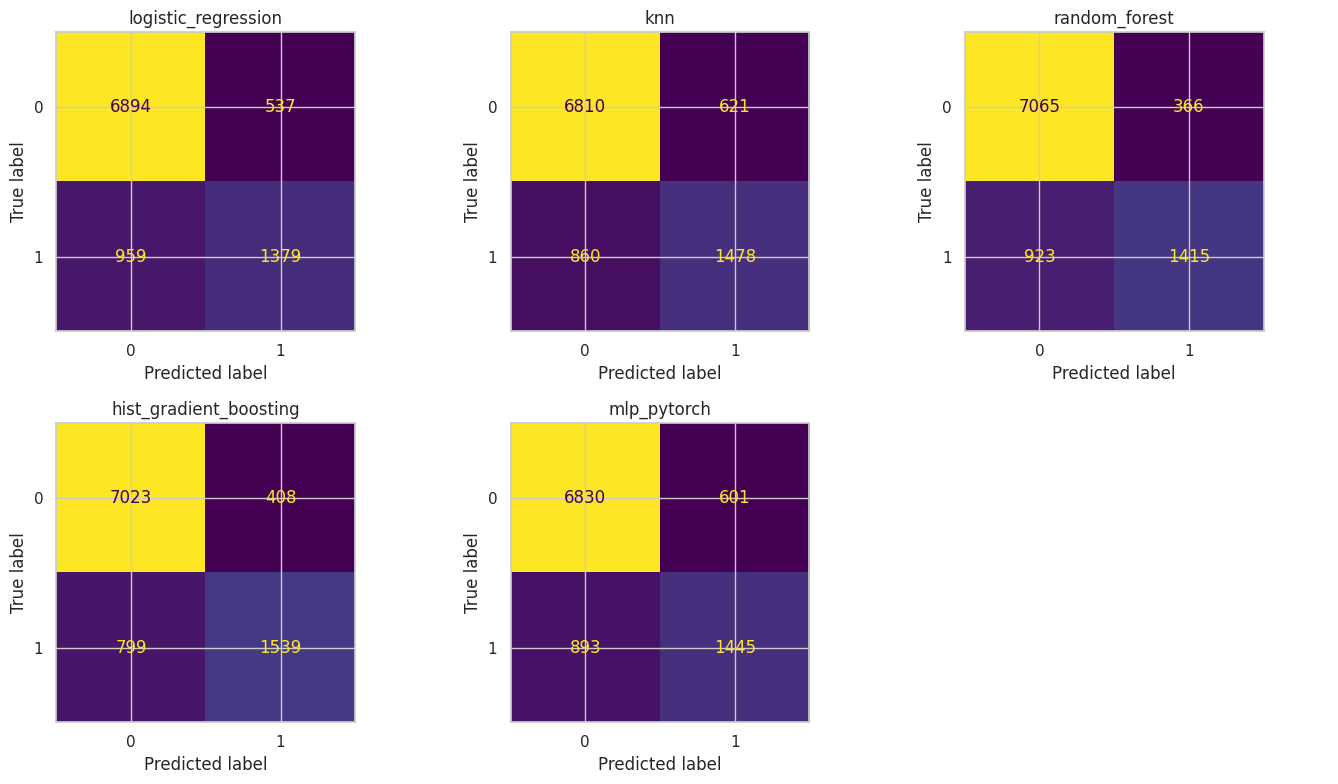

In [35]:
n_models = len(fitted_models)
n_cols = 3
n_rows = -(-n_models // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, (name, model) in zip(axes, fitted_models.items()):
    X_eval = X_test_t if name == "mlp_pytorch" else X_test_enc
    preds = model.predict(X_eval)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(name)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Freezing the winning pipeline

The best-performing model on held-out F1 is bundled together with the
already-fitted `preprocessor` into a single `Pipeline`, so at inference time
raw feature values go in one end and a prediction comes out the other — no
separate encoder/scaler bookkeeping required outside the notebook.

In [ ]:
best_name = leaderboard_df.iloc[0]["model"]
print("Selected model:", best_name)

if best_name == "mlp_pytorch":
    
    best_name = leaderboard_df[leaderboard_df["model"] != "mlp_pytorch"].iloc[0]["model"]
    print("(torch model can't join a sklearn Pipeline — using runner-up instead:", best_name, ")")

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", fitted_models[best_name]),
])

final_pipeline.named_steps["classifier"].fit(preprocessor.transform(X_train), y_train)

Selected model: hist_gradient_boosting


HistGradientBoostingClassifier(random_state=42)

In [37]:
joblib.dump(final_pipeline, os.path.join(ARTIFACT_DIR, "pipeline.joblib"))

joblib.dump(
    {
        "education_order": EDUCATION_ORDER,
        "education_map": _education_map,
        "feature_cols": feature_cols,
        "model_name": best_name,
    },
    os.path.join(ARTIFACT_DIR, "metadata.joblib"),
)

print("Saved to", ARTIFACT_DIR)

Saved to artifacts
